# ML Modeling — Salary Prediction
Train & evaluate salary prediction models.

# 1. Load libraries

In [1]:
import sys
from pathlib import Path
# Adjust path to find src/ from the notebooks/ folder
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import pickle
from src.data_loader import load_all_jobs
from src.utils import MODELS_DIR, logger

sns.set_style("whitegrid")
OUTPUT_DIR = Path.cwd().parent / "visuals"
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Load & Prepare Data

In [3]:
df = load_all_jobs()
print(f"Loaded: {len(df):,} rows")

Loaded: 555 rows


In [4]:
# Encode categorical columns
le_dict = {}
cat_cols = ["experience_level", "employment_type", "job_title", "company_location", "company_size"]
for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col + "_enc"] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

In [5]:
# Feature matrix
feature_cols = [c for c in df.columns if c.endswith("_enc")] + ["remote_ratio", "work_year"]
X = df[feature_cols].fillna(0)
y = df["salary_in_usd"]

In [6]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 444 | Test: 111


## 3. Train Multiple Models

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, objective="reg:squarederror", random_state=42, verbosity=0),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),}

In [8]:
results = []

for name, model in models.items():
    print(f"\n{'─' * 40}")
    print(f"Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    cv_mean = cv_scores.mean()

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "CV R² (mean)": cv_mean,
    })

    print(f"  MAE: ${mae:,.0f}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  R²: {r2:.4f}")
    print(f"  CV R²: {cv_mean:.4f} (±{cv_scores.std():.4f})")

    # Save best model
    if name == "LightGBM":
        MODELS_DIR.mkdir(exist_ok=True)
        with open(MODELS_DIR / "salary_predictor_lgb.pkl", "wb") as f:
            pickle.dump(model, f)
        logger.info("Saved: models/salary_predictor_lgb.pkl")


────────────────────────────────────────
Training: Linear Regression
  MAE: $35,245
  RMSE: $46,061
  R²: 0.3631
  CV R²: 0.2418 (±0.0486)

────────────────────────────────────────
Training: Random Forest
  MAE: $28,665
  RMSE: $39,592
  R²: 0.5295
  CV R²: 0.4477 (±0.0598)

────────────────────────────────────────
Training: XGBoost
  MAE: $29,505
  RMSE: $40,892
  R²: 0.4980
  CV R²: 0.3936 (±0.0630)

────────────────────────────────────────
Training: LightGBM


2026-08-06 07:42:22,956 [INFO] job_market_v4: Saved: models/salary_predictor_lgb.pkl


  MAE: $28,226
  RMSE: $38,084
  R²: 0.5646
  CV R²: 0.4961 (±0.0511)


## 4. Model Comparison

In [9]:
results_df = pd.DataFrame(results).set_index("Model")
print(results_df.to_string())

                            MAE          RMSE        R²  CV R² (mean)
Model                                                                
Linear Regression  35245.024168  46061.349522  0.363122      0.241817
Random Forest      28664.828867  39592.228734  0.529453      0.447721
XGBoost            29505.273438  40892.425509  0.498041      0.393615
LightGBM           28225.945443  38083.747406  0.564626      0.496135


## 5. Feature Importance (LightGBM)

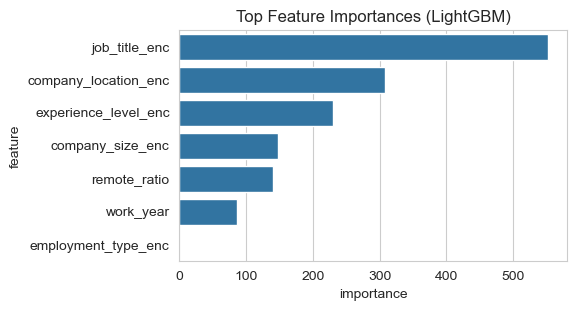


✓ feature_importance.png saved


In [10]:
best_model = models["LightGBM"]
importance = pd.DataFrame({"feature": feature_cols, "importance": best_model.feature_importances_}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(data=importance.head(15), x="importance", y="feature", ax=ax)
ax.set_title("Top Feature Importances (LightGBM)")
fig.savefig(OUTPUT_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ feature_importance.png saved")

## 6. Residual Plot

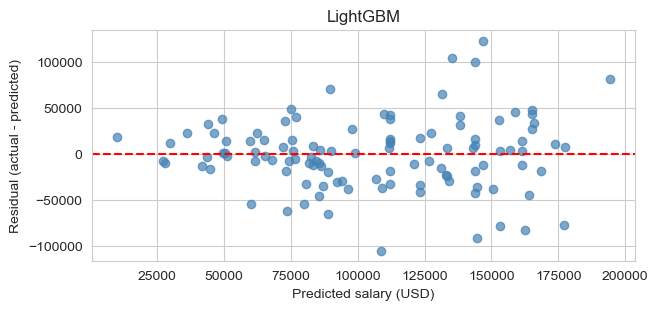

✓ residual_plot.png saved

 ML Modeling complete! Model saved to models/salary_predictor_lgb.pkl


In [11]:
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(y_pred_best, residuals, alpha=0.7, color="steelblue")
ax.axhline(y=0, color="red", linestyle="--")
ax.set_xlabel("Predicted salary (USD)")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("LightGBM")
fig.savefig(OUTPUT_DIR / "residual_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ residual_plot.png saved")
print("\n ML Modeling complete! Model saved to models/salary_predictor_lgb.pkl")